# Create `Splice-Junction-to-RBP-Number-of-Peaks` Dictionary

## Purpose: 

* Take `bedtools closest` output and clean it up. 
* Create dictionary of splice junction to number of times RBP binds. 
* Output dictionary. 

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, pickle, gzip
import matplotlib.pyplot as plt

## Literals

In [2]:
cell_lines = ["K562", "HepG2"]
thresholds = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 500, 1000, 2000, 5000, 10000]

## Load and Clean `BedTools Closest` Output

In [3]:
eclip_to_splice_junctions = {}

for cell_line in cell_lines:
    file = glob.glob("../output/peaks_to_splice_junctions/{}*.bed".format(cell_line))
    assert len(file)==1
    
    tmp_mappings = pd.read_csv(file[0], sep="\t", header=None)
    "Before filtering out missing mappings: {}".format(tmp_mappings.index.size)
    
    # get the distance column (last column in bed file
    distance_column = tmp_mappings.columns[-1]
    # remove the peaks that did not have any splice junctions to map to    
    tmp_mappings = tmp_mappings[tmp_mappings[distance_column]>=0]

    assert (tmp_mappings[5]==tmp_mappings[11]).all()
    "After filtering out missing mappings: {}".format(tmp_mappings.index.size)

    tmp_mappings = tmp_mappings.sample(frac=1, random_state=17).drop_duplicates([0,1,2,3,4,5], keep='first')
    tmp_mappings = tmp_mappings.sort_index()
    
    ties = tmp_mappings.groupby([0,1,2,3,4,5]).size()
    assert (ties==1).all()
    "After removing duplicate eCLIP assignments: {}".format(tmp_mappings.index.size)

    assert not tmp_mappings.duplicated(subset=[0,1,2,3,4,5], keep=False).any()
    # filter for the RBP, unique splice junction ID, and distance columns
    tmp_mappings = tmp_mappings[[3, 9, distance_column]]
    
    # parse out RBP column
    tmp_mappings["RBP"] = tmp_mappings[3].str.split("_").str[0]
    # change column names for clarity
    tmp_mappings = tmp_mappings.rename(
        columns={
            9: "Splice Junction ID", 
            12: "Distance"
        }
    )
    
    # ensure there are no null values in matrix 
    assert tmp_mappings.notnull().all().all()
    
    tmp_mappings.head()  
    tmp_mappings["Distance"].min()
    
    # save the refined dataset
    eclip_to_splice_junctions[cell_line] = tmp_mappings

'Before filtering out missing mappings: 478325'

'After filtering out missing mappings: 477328'

'After removing duplicate eCLIP assignments: 462407'

,3,Splice Junction ID,Distance,RBP
0,AQR_K562_IDR,chr1_15947_-,0,AQR
1,BUD13_K562_IDR,chr1_16606_-,276,BUD13
2,AQR_K562_IDR,chr1_16606_-,288,AQR
3,AQR_K562_IDR,chr1_16606_-,97,AQR
4,EXOSC10_K562_IDR,chr1_17605_-,69,EXOSC10


0

'Before filtering out missing mappings: 469172'

'After filtering out missing mappings: 468476'

'After removing duplicate eCLIP assignments: 454082'

,3,Splice Junction ID,Distance,RBP
0,PRPF4_HepG2_IDR,chr1_17605_-,39,PRPF4
1,EFTUD2_HepG2_IDR,chr1_17605_-,56,EFTUD2
2,PABPN1_HepG2_IDR,chr1_185216_-,87,PABPN1
3,PRPF8_HepG2_IDR,chr1_187128_-,0,PRPF8
4,PPIG_HepG2_IDR,chr1_187577_-,13,PPIG


0

## Get Dictionary of Splice Junction to RBPs Bound


**Dictionary structure**: 

```
{
    cell_line: {
        distance threshold:{
            splice junction id: {
                RBP name: # eCLIP Peaks 
            }
        }
    }
}
```

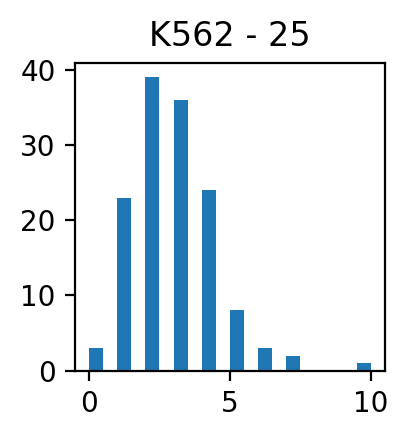

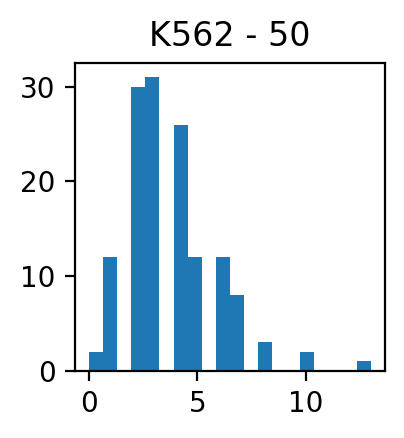

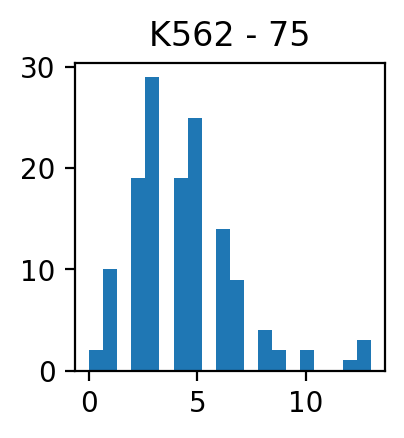

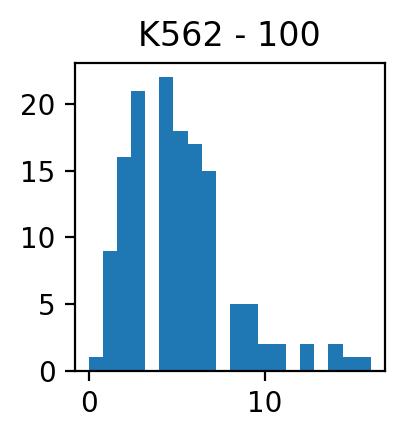

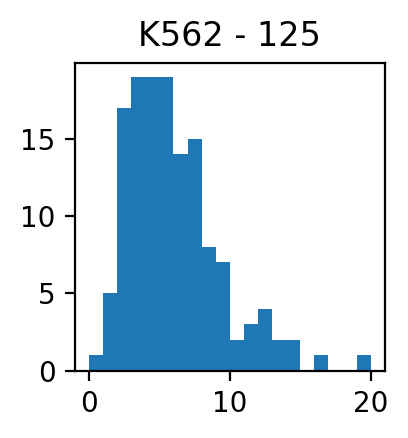

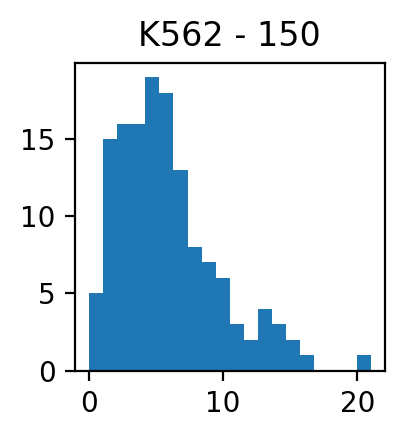

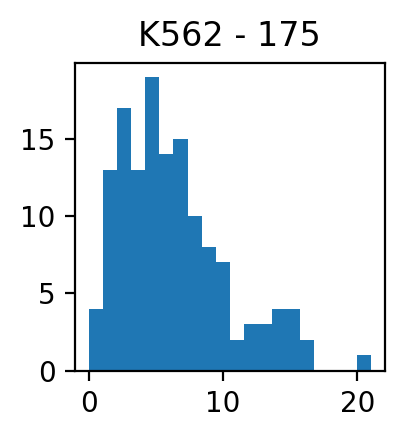

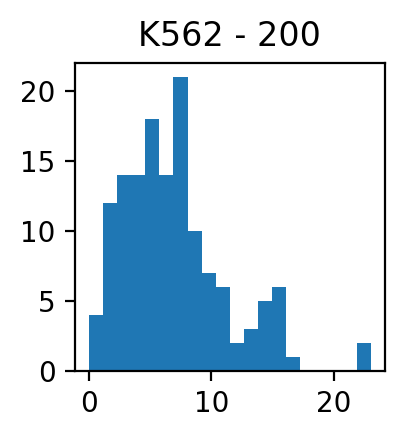

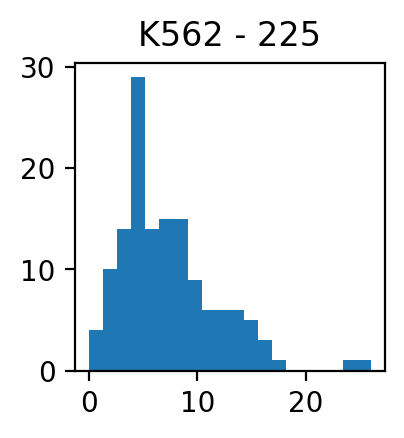

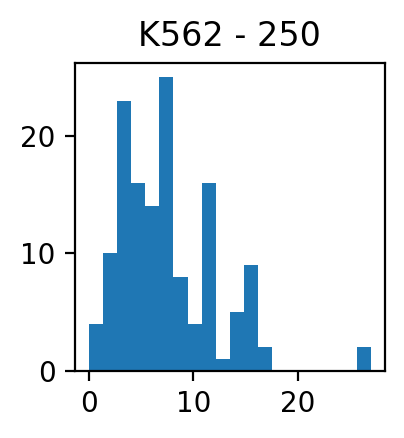

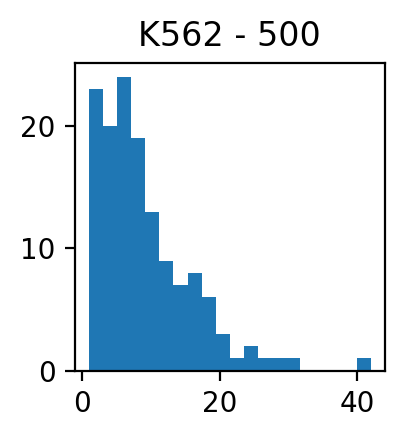

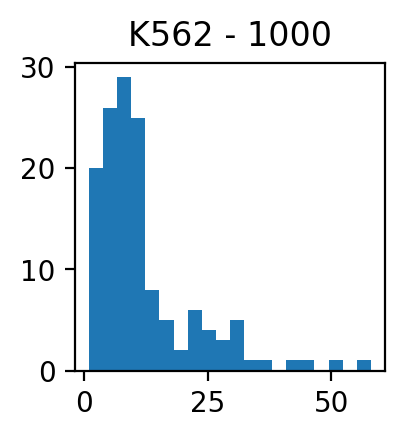

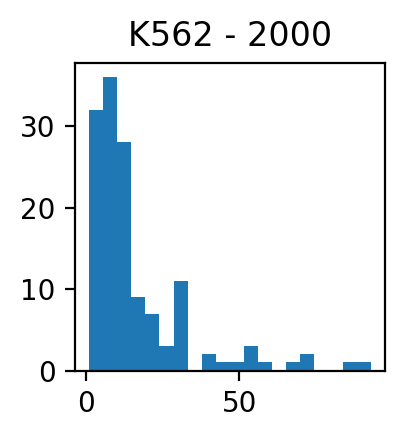

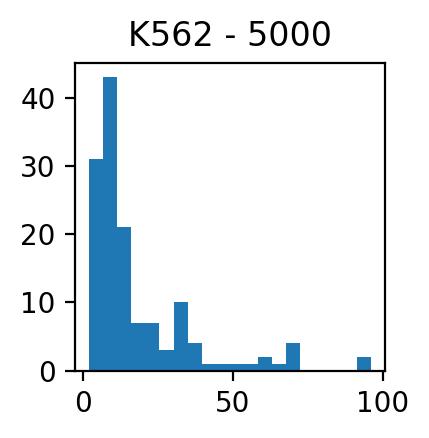

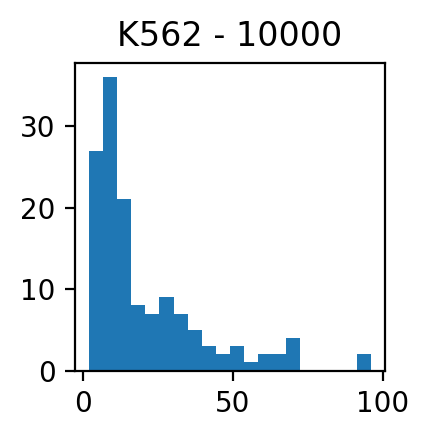

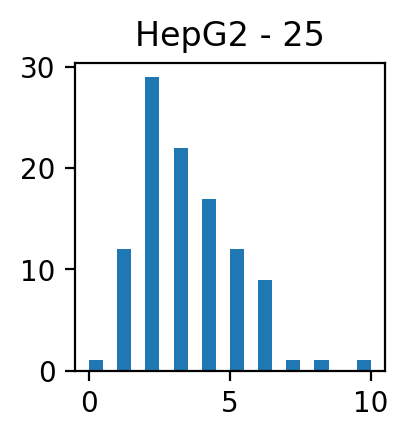

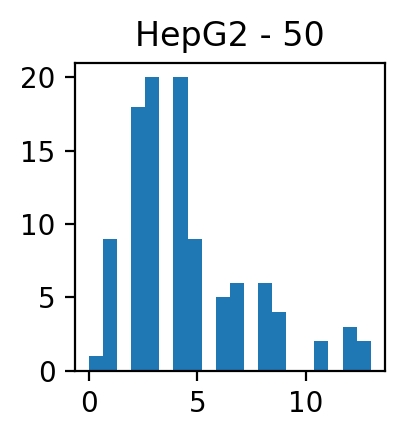

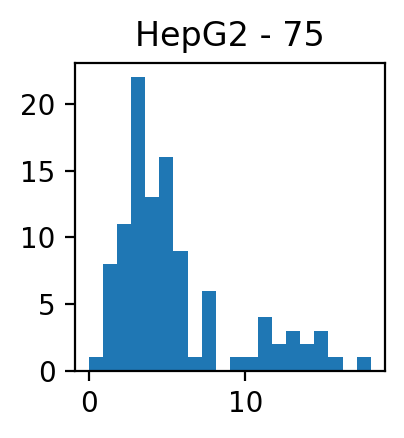

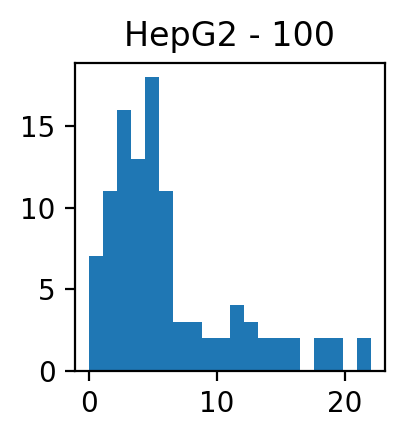

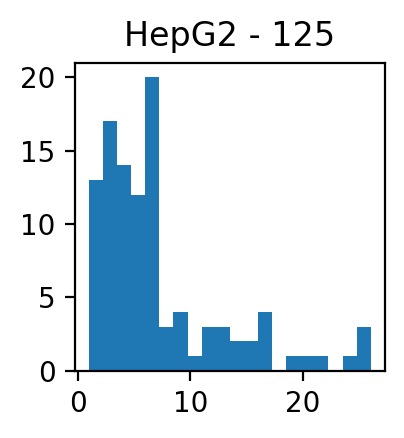

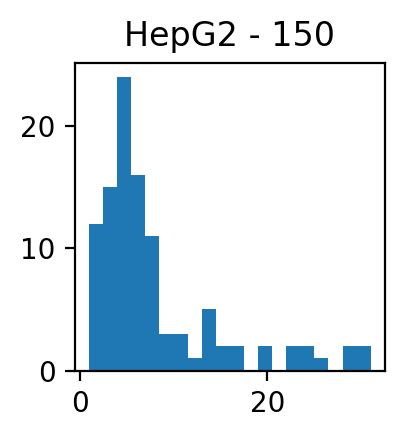

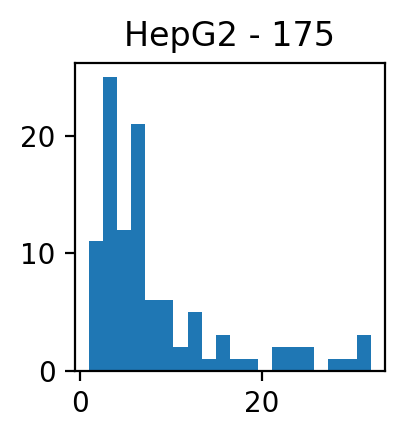

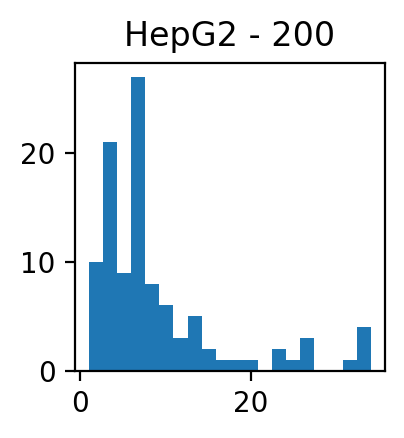

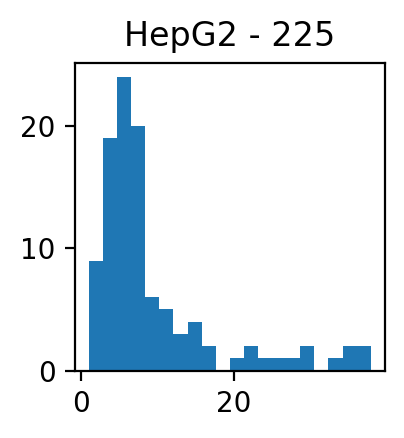

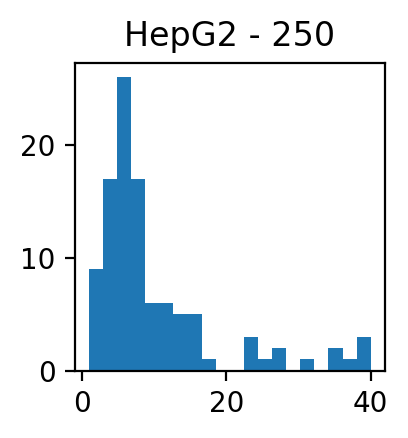

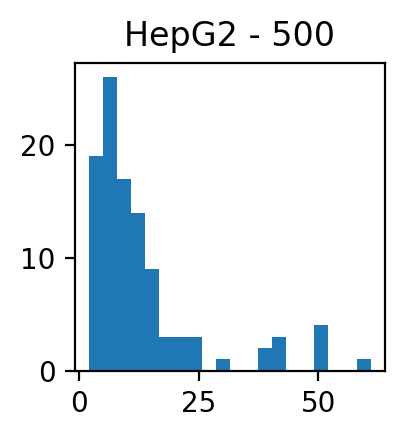

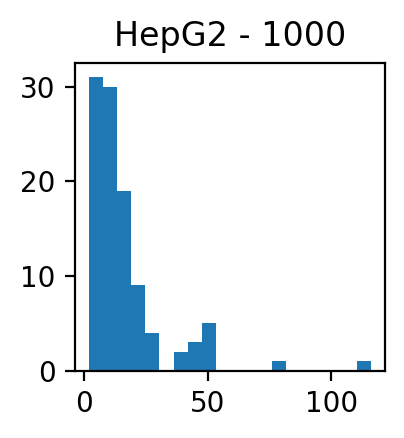

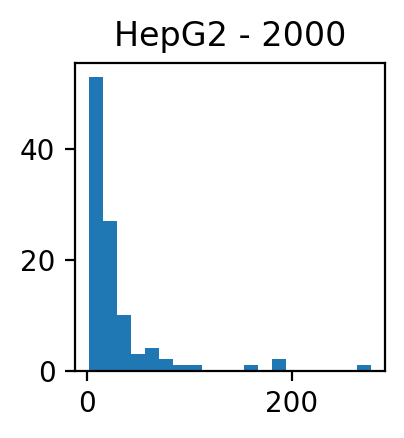

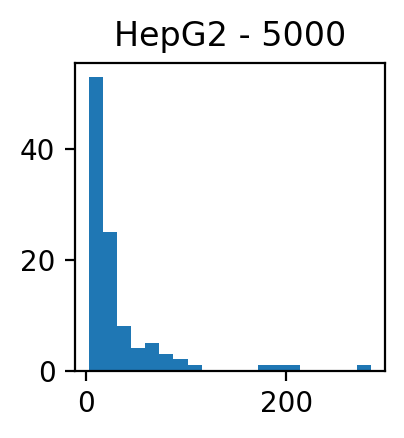

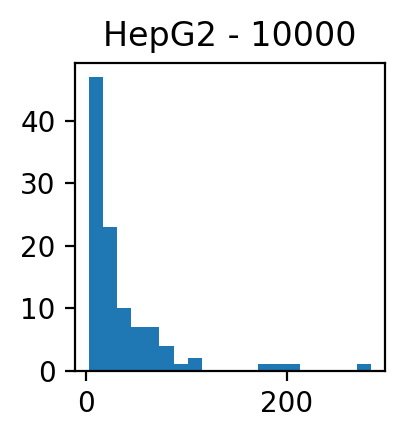

In [4]:
# dict following paradigm described above 
all_splice_junction_to_rbp_num_peaks = {}

# for each cell line 
for cell_line in cell_lines:
    
    # get all eCLIP to splice junction mappings for the cell line 
    cell_line_mappings = eclip_to_splice_junctions[cell_line]
    
    all_splice_junction_to_rbp_num_peaks[cell_line] = {}
    
    # for each distance threshold 
    for threshold in thresholds: 
        
        # subset to less than distance 
        # THIS ASSUMES THAT ALL DISTANCES ARE POSITIVE
        threshold_mappings = cell_line_mappings[cell_line_mappings["Distance"]<=threshold]
        
        # get a count for the number of peaks of a given RBP at a specific splice junction for a distance threshold 
        # use pd.unstack method to convert output series into a 2D matrix where null values are made into 0
        threshold_mappings = threshold_mappings.groupby(["Splice Junction ID", "RBP"]).size().unstack(fill_value=0)
        
        # get the rbps that should be included in the dataset but had no data show up 
        # (we need to indicate that these data are available but are all "0" values)
        missing_rbps = set(cell_line_mappings["RBP"].unique().tolist()) - set(threshold_mappings.columns.to_list())
            
        # if there are missing rbps 
        if len(missing_rbps)>0: 
            # fill all values for the rbp as 0 
            for rbp in missing_rbps: 
                threshold_mappings[rbp] = 0
        
        # sort RBP columns by name 
        threshold_mappings = threshold_mappings.sort_index(axis=1)
        assert threshold_mappings.max().max() >1

        _=plt.figure(figsize=(2,2), dpi=200)
        _=plt.hist(threshold_mappings.max(), bins=20)
        _=plt.title(f"{cell_line} - {threshold}")
        plt.show()
        
        # convert datafraem to dict whereby first key is splice junciton id and value is another dict where 
        # sub-dict key is RBP name and value is number of peaks
        all_splice_junction_to_rbp_num_peaks[cell_line][threshold] = threshold_mappings.to_dict(orient="index")

## Output Dictionary as `GZIP Pickle` File

In [5]:
with gzip.GzipFile("../output/splice_junction_rbp_num_peaks/all_RBP_peaks_num_per_splice_junction.pkl.gz", 'wb') as file: 
    pickle.dump(all_splice_junction_to_rbp_num_peaks, file)

In [6]:
with gzip.GzipFile("../output/splice_junction_rbp_num_peaks/all_RBP_peaks_num_per_splice_junction.pkl.gz", 'rb') as file:
    all_splice_junction_to_rbp_num_peaks = pickle.load(file)

In [7]:
print(all_splice_junction_to_rbp_num_peaks["K562"][100]['chr10_101798154_-'])

{'AARS': 0, 'AATF': 0, 'ABCF1': 0, 'ADAT1': 0, 'AGGF1': 0, 'AKAP1': 0, 'AKAP8L': 0, 'APEX1': 0, 'APOBEC3C': 0, 'AQR': 0, 'BUD13': 0, 'CPEB4': 0, 'CPSF6': 0, 'CSTF2T': 0, 'DDX1': 0, 'DDX21': 0, 'DDX24': 0, 'DDX3X': 0, 'DDX42': 0, 'DDX43': 0, 'DDX47': 0, 'DDX51': 0, 'DDX52': 0, 'DDX55': 0, 'DDX6': 0, 'DGCR8': 0, 'DHX30': 0, 'DROSHA': 0, 'EEF2': 0, 'EFTUD2': 0, 'EIF3G': 0, 'EIF4E': 0, 'EIF4G2': 0, 'ELAC2': 0, 'ELAVL1': 0, 'EWSR1': 0, 'EXOSC10': 0, 'EXOSC5': 0, 'FAM120A': 0, 'FASTKD2': 0, 'FMR1': 0, 'FTO': 0, 'FUS': 0, 'FXR1': 0, 'FXR2': 0, 'GARS': 0, 'GEMIN5': 0, 'GNL3': 0, 'GPKOW': 0, 'GRWD1': 0, 'GTF2F1': 0, 'HLTF': 0, 'HNRNPA1': 0, 'HNRNPC': 0, 'HNRNPK': 0, 'HNRNPL': 0, 'HNRNPM': 0, 'HNRNPU': 0, 'HNRNPUL1': 0, 'IGF2BP1': 0, 'IGF2BP2': 0, 'ILF3': 0, 'KHDRBS1': 0, 'KHSRP': 0, 'LARP4': 0, 'LARP7': 0, 'LIN28B': 0, 'LSM11': 0, 'MATR3': 0, 'MBNL1': 0, 'METAP2': 0, 'METTL1': 0, 'MORC2': 0, 'MTPAP': 0, 'NCBP2': 0, 'NIPBL': 0, 'NOLC1': 0, 'NONO': 0, 'NPM1': 0, 'NSUN2': 0, 'PABPC4': 0, 'PCBP1': 